# Groundhog Day Predictions - Exploratory Data Analysis

This notebook explores the Groundhog Day API data for Bayesian analysis.

**Data Source:** https://groundhog-day.com/api/v1/

**Key Variables:**
- `shadow`: 1 = saw shadow (6 more weeks of winter), 0 = no shadow (early spring)
- `year`: Year of prediction (1886-2022)
- `groundhog`: Metadata about each prognosticating animal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import json
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries imported successfully")

Libraries imported successfully


## Load and Process Data

In [2]:
# Load the combined data
with open('data/combined_data.json', 'r') as f:
    data = json.load(f)

# Extract groundhogs info
groundhogs = data['groundhogs']
predictions_by_year = data['predictions_by_year']

print(f"Number of groundhogs: {len(groundhogs)}")
print(f"Year range: {data['metadata']['year_range']}")
print(f"Fetched at: {data['metadata']['fetched_at']}")

Number of groundhogs: 88
Year range: {'min': 1886, 'max': 2022}
Fetched at: 2026-02-02T22:34:36.720184Z


In [6]:
# Create a flat DataFrame of all predictions
all_predictions = []

for year, year_payload in predictions_by_year.items():
    year_preds = year_payload.get('predictions') if isinstance(year_payload, dict) else year_payload
    if not year_preds:
        continue
    for pred in year_preds:
        pred = dict(pred)
        pred['year'] = int(year)
        all_predictions.append(pred)

df = pd.DataFrame(all_predictions)

# Extract groundhog info into separate columns
groundhog_df = pd.json_normalize(df['groundhog'])
df = pd.concat([df.drop('groundhog', axis=1), groundhog_df], axis=1)

print(f"Total predictions: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")

Total predictions: 1445

Columns: ['year', 'shadow', 'details', 'id', 'slug', 'shortname', 'name', 'city', 'region', 'country', 'coordinates', 'source', 'contact', 'currentPrediction', 'predictionsCount', 'isGroundhog', 'type', 'active', 'successor', 'description', 'image']


In [7]:
df

,year,shadow,details,id,slug,shortname,name,city,region,country,...,source,contact,currentPrediction,predictionsCount,isGroundhog,type,active,successor,description,image
0,1886,NaN,Groundhog Day first recognized in Punxsutawney...,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...
1,1887,1.0,First Official trek to Gobbler’s Knob. Saw Sha...,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...
2,1888,1.0,Saw Shadow.,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...
3,1889,NaN,No Record.,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...
4,1890,0.0,No Shadow.,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1440,2022,0.0,,79,queen-city-charlie,Charlie,Queen City Charlie,Cumberland,Maryland,USA,...,https://www.facebook.com/cityofcumberlandmd,melinda.kelleher@cumberlandmd.gov,https://www.facebook.com/cityofcumberlandmd/po...,5,0,Person in a groundhog suit,1,,Queen City Charlie is a prognosticating person...,https://groundhog-day.com/images/ghogs/queen-c...
1441,2022,0.0,,80,unadilla-billie,Billie,Unadilla Billie,Unadilla,Nebraska,USA,...,https://www.facebook.com/profile.php?id=100064...,,https://www.facebook.com/awardnewsguy/posts/pf...,5,0,Taxidermied groundhog,1,,Unadilla Billie is a taxidermied lady groundho...,https://groundhog-day.com/images/ghogs/unadill...
1442,2022,1.0,,78,poppy-the-groundhog,Poppy,Poppy the Groundhog,Millersville,Pennsylvania,USA,...,https://www.facebook.com/AcornAcresWR,info@acornacreswr.com,https://lancasteronline.com/poppy-and-her-new-...,4,1,Groundhog,0,elliott-the-groundhog,Poppy the Groundhog was internationally known ...,https://groundhog-day.com/images/ghogs/poppy-t...
1443,2022,0.0,,75,heavens-wildlife-harvey,Harvey,Heaven’s Wildlife Harvey,Oil Springs,Ontario,Canada,...,https://www.facebook.com/profile.php?id=100068...,,https://www.theobserver.ca/news/local-news/ear...,3,1,Groundhog,0,,Heaven’s Wildlife Harvey is a somewhat rotund ...,https://groundhog-day.com/images/ghogs/heavens...


In [8]:
# Display basic info about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head(10)

Dataset Shape: (1445, 21)

First few rows:


,year,shadow,details,id,slug,shortname,name,city,region,country,...,source,contact,currentPrediction,predictionsCount,isGroundhog,type,active,successor,description,image
0,1886,NaN,Groundhog Day first recognized in Punxsutawney...,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...
1,1887,1.0,First Official trek to Gobbler’s Knob. Saw Sha...,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...
2,1888,1.0,Saw Shadow.,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...
3,1889,NaN,No Record.,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...
4,1890,0.0,No Shadow.,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...
5,1891,NaN,No Record.,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...
6,1892,NaN,No Record.,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...
7,1893,NaN,No Record.,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...
8,1894,NaN,No Record.,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...
9,1895,NaN,No Record.,1,punxsutawney-phil,Phil,Punxsutawney Phil,Punxsutawney,Pennsylvania,USA,...,https://www.groundhog.org/history-past-predict...,,https://www.stormfax.com/ghogday.htm,131,1,Groundhog,1,,Punxsutawney Phil is a superstar prognosticati...,https://groundhog-day.com/images/ghogs/punxsut...


In [9]:
# Clean up the shadow column (handle nulls)
print("Shadow value counts:")
print(df['shadow'].value_counts(dropna=False))

# Create binary shadow indicator (excluding nulls)
df['shadow_binary'] = df['shadow'].apply(lambda x: 1 if x == 1 else (0 if x == 0 else np.nan))
print(f"\nValid predictions (non-null shadow): {df['shadow_binary'].notna().sum()}")

Shadow value counts:
shadow
1.0    664
0.0    634
NaN    147
Name: count, dtype: int64

Valid predictions (non-null shadow): 1298


## Overall Shadow Statistics

In [10]:
# Calculate overall shadow rate
valid_df = df[df['shadow_binary'].notna()]
overall_shadow_rate = valid_df['shadow_binary'].mean()

print("=" * 50)
print("OVERALL SHADOW STATISTICS")
print("=" * 50)
print(f"Total valid predictions: {len(valid_df)}")
print(f"Saw shadow: {valid_df['shadow_binary'].sum():.0f} ({overall_shadow_rate*100:.1f}%)")
print(f"No shadow: {(1-valid_df['shadow_binary']).sum():.0f} ({(1-overall_shadow_rate)*100:.1f}%)")

OVERALL SHADOW STATISTICS
Total valid predictions: 1298
Saw shadow: 664 (51.2%)
No shadow: 634 (48.8%)


In [11]:
# Year-by-year shadow rate
yearly_stats = valid_df.groupby('year').agg({
    'shadow_binary': ['sum', 'count', 'mean']
}).reset_index()
yearly_stats.columns = ['year', 'shadow_count', 'total_count', 'shadow_rate']

print("\nYearly statistics (first 20 years):")
print(yearly_stats.head(20))


Yearly statistics (first 20 years):
    year  shadow_count  total_count  shadow_rate
0   1887           1.0            1          1.0
1   1888           1.0            1          1.0
2   1890           0.0            1          0.0
3   1898           1.0            1          1.0
4   1900           1.0            1          1.0
5   1901           1.0            1          1.0
6   1902           0.0            1          0.0
7   1903           1.0            1          1.0
8   1904           1.0            1          1.0
9   1905           1.0            1          1.0
10  1906           1.0            1          1.0
11  1907           1.0            1          1.0
12  1908           1.0            1          1.0
13  1909           1.0            1          1.0
14  1910           1.0            1          1.0
15  1911           1.0            1          1.0
16  1912           1.0            1          1.0
17  1913           1.0            1          1.0
18  1914           1.0          

## Visualizations

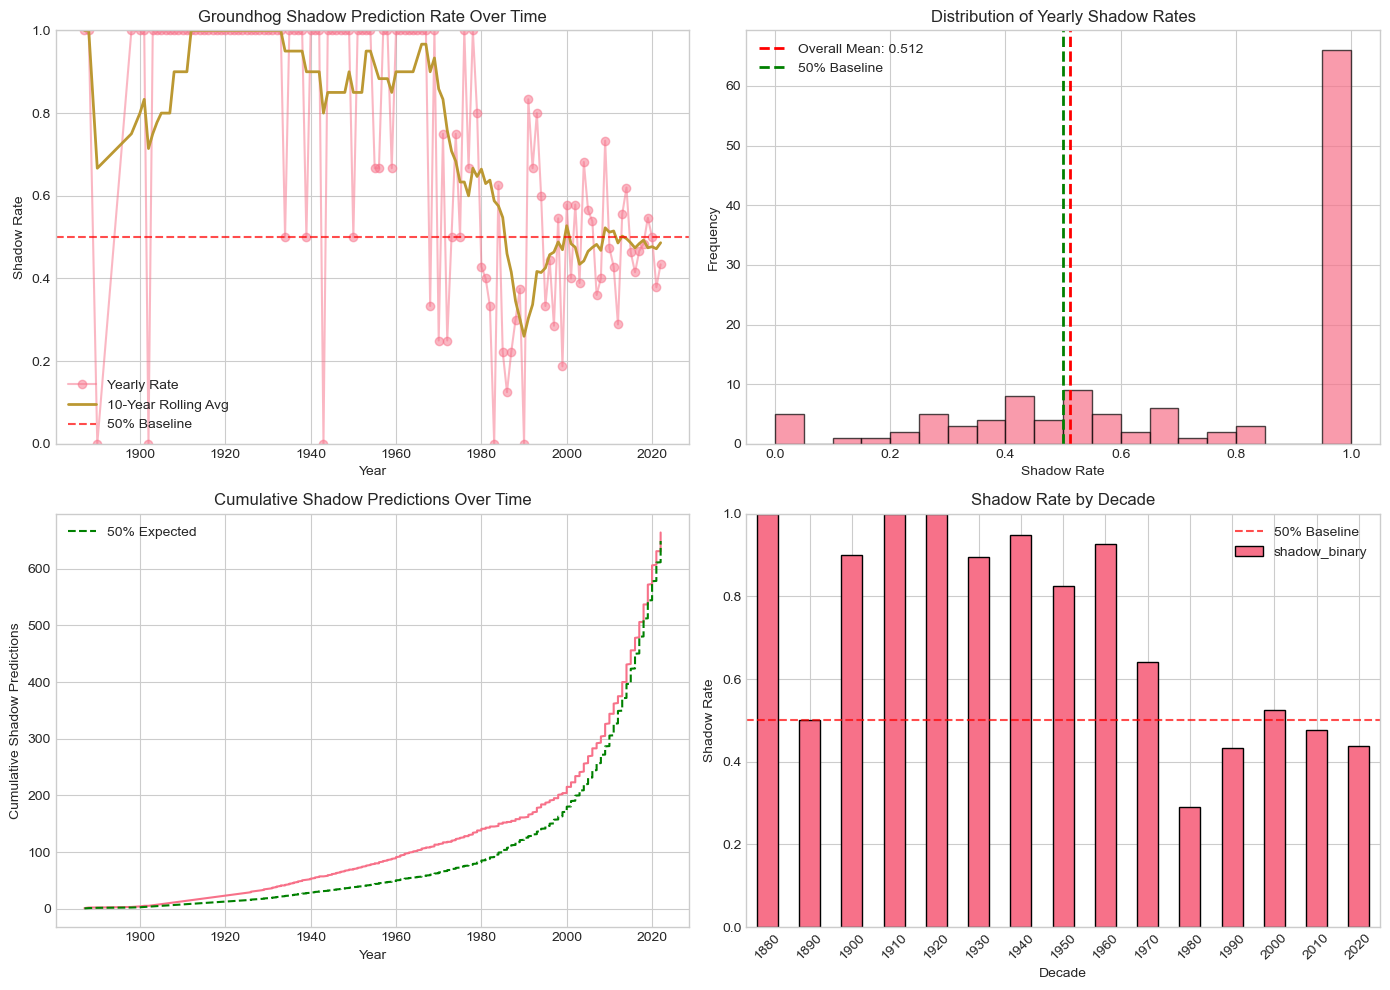


Visualization saved to data/shadow_analysis.png


In [12]:
# Time series of shadow predictions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Shadow rate over time (rolling average)
ax1 = axes[0, 0]
yearly_stats['rolling_rate'] = yearly_stats['shadow_rate'].rolling(window=10, min_periods=1).mean()
ax1.plot(yearly_stats['year'], yearly_stats['shadow_rate'], 'o-', alpha=0.5, label='Yearly Rate')
ax1.plot(yearly_stats['year'], yearly_stats['rolling_rate'], '-', linewidth=2, label='10-Year Rolling Avg')
ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='50% Baseline')
ax1.set_xlabel('Year')
ax1.set_ylabel('Shadow Rate')
ax1.set_title('Groundhog Shadow Prediction Rate Over Time')
ax1.legend()
ax1.set_ylim(0, 1)

# Plot 2: Distribution of yearly shadow rates
ax2 = axes[0, 1]
ax2.hist(yearly_stats['shadow_rate'], bins=20, edgecolor='black', alpha=0.7)
ax2.axvline(x=overall_shadow_rate, color='red', linestyle='--', linewidth=2, label=f'Overall Mean: {overall_shadow_rate:.3f}')
ax2.axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='50% Baseline')
ax2.set_xlabel('Shadow Rate')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Yearly Shadow Rates')
ax2.legend()

# Plot 3: Cumulative shadow predictions
ax3 = axes[1, 0]
valid_df_sorted = valid_df.sort_values('year')
cumulative_shadows = valid_df_sorted['shadow_binary'].cumsum()
ax3.plot(valid_df_sorted['year'], cumulative_shadows, '-')
ax3.plot(valid_df_sorted['year'], np.arange(1, len(cumulative_shadows)+1)*0.5, '--', color='green', label='50% Expected')
ax3.set_xlabel('Year')
ax3.set_ylabel('Cumulative Shadow Predictions')
ax3.set_title('Cumulative Shadow Predictions Over Time')
ax3.legend()

# Plot 4: Bar chart of decades
ax4 = axes[1, 1]
valid_df['decade'] = (valid_df['year'] // 10) * 10
decade_stats = valid_df.groupby('decade')['shadow_binary'].mean()
decade_stats.plot(kind='bar', ax=ax4, edgecolor='black')
ax4.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='50% Baseline')
ax4.set_xlabel('Decade')
ax4.set_ylabel('Shadow Rate')
ax4.set_title('Shadow Rate by Decade')
ax4.legend()
ax4.set_ylim(0, 1)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data/shadow_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved to data/shadow_analysis.png")

## Groundhog Analysis

In [13]:
# Analyze groundhog types and their predictions
print("=" * 50)
print("GROUNDHOG ANALYSIS")
print("=" * 50)

# Groundhog types
print("\nGroundhog Types:")
print(df['type'].value_counts())

# Country distribution
print("\nCountry Distribution:")
print(df['country'].value_counts())

GROUNDHOG ANALYSIS

Groundhog Types:
type
Groundhog                               788
Taxidermied groundhog                   188
Person in a groundhog suit               60
Presumed groundhog                       44
Statue of a prairie dog                  38
Plush prairie dog                        32
Plush groundhog                          29
Groundhog golf club cover                27
Groundhog puppet                         24
Desert tortoise                          23
Prairie dog                              21
Person in a gopher suit                  19
Plush yellow-bellied marmot              17
Bullfrog                                 17
Taxidermied groundhogs                   16
Opossum                                  15
Armadillo                                14
Taxidermied yellow-bellied marmot        13
Animatronic groundhog                     9
Largemouth bass                           8
Pekin duck                                8
Vancouver Island marmot           

In [15]:
# Analyze predictions by groundhog
groundhog_stats = valid_df.groupby(['slug', 'shortname', 'type', 'country']).agg({
    'shadow_binary': ['count', 'sum', 'mean']
}).reset_index()
groundhog_stats.columns = ['slug', 'shortname', 'type', 'country', 'predictions', 'shadows', 'shadow_rate']
groundhog_stats = groundhog_stats.sort_values('predictions', ascending=False)

print("\nTop 15 Most Active Groundhogs:")
print(groundhog_stats.head(15).to_string())


Top 15 Most Active Groundhogs:
                      slug     shortname                       type country  predictions  shadows  shadow_rate
55       punxsutawney-phil          Phil                  Groundhog     USA          127    107.0     0.842520
46         octoraro-orphie        Orphie      Taxidermied groundhog     USA           90     72.0     0.800000
76          wiarton-willie        Willie                  Groundhog  Canada           59     25.0     0.423729
33     jimmy-the-groundhog         Jimmy                  Groundhog     USA           54     22.0     0.407407
18         concord-charlie       Charlie         Presumed groundhog     USA           44     18.0     0.409091
25  general-beauregard-lee          Beau                  Groundhog     USA           39      4.0     0.102564
9            buckeye-chuck         Chuck                  Groundhog     USA           39     11.0     0.282051
24    french-creek-freddie       Freddie                  Groundhog     USA     


Shadow Rate by Groundhog Type:
                                    type  count  mean_shadow_rate       std
9                              Groundhog    719          0.479833  0.499941
25                 Taxidermied groundhog    169          0.763314  0.426311
16            Person in a groundhog suit     51          0.352941  0.482640
23                    Presumed groundhog     44          0.409091  0.497350
19                       Plush groundhog     27          0.444444  0.506370
10             Groundhog golf club cover     25          0.400000  0.500000
24               Statue of a prairie dog     25          0.400000  0.500000
8                        Desert tortoise     23          0.739130  0.448978
20                     Plush prairie dog     22          0.318182  0.476731
22                           Prairie dog     19          0.210526  0.418854
11                      Groundhog puppet     18          0.777778  0.427793
15               Person in a gopher suit     18         

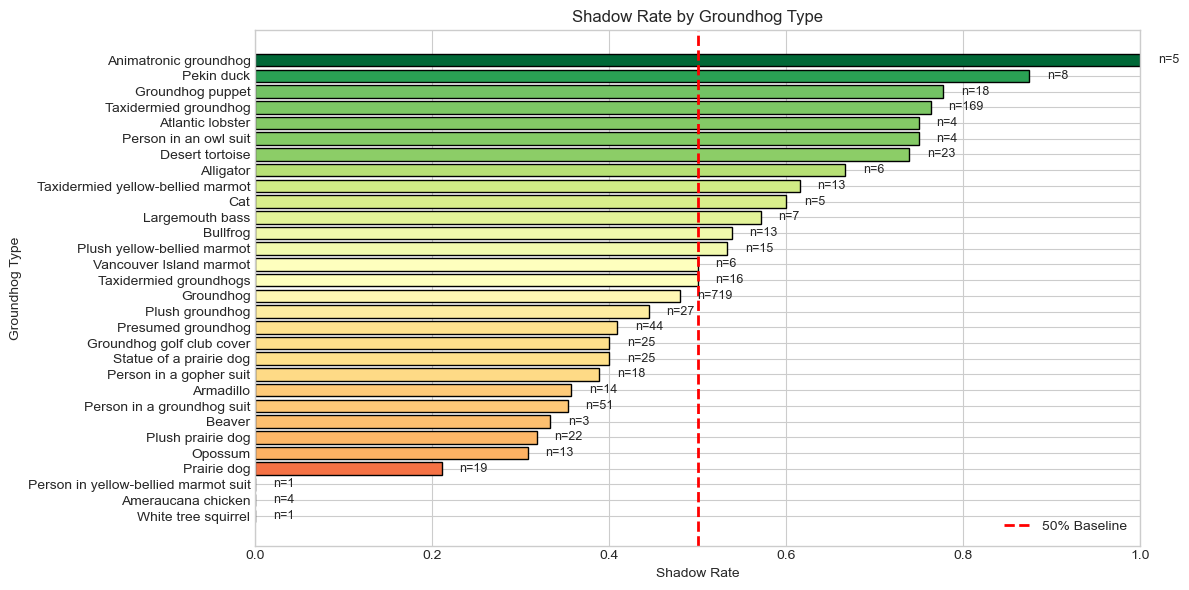

In [16]:
# Shadow rate by groundhog type
type_stats = valid_df.groupby('type')['shadow_binary'].agg(['count', 'mean', 'std']).reset_index()
type_stats.columns = ['type', 'count', 'mean_shadow_rate', 'std']
type_stats = type_stats.sort_values('count', ascending=False)

print("\nShadow Rate by Groundhog Type:")
print(type_stats.to_string())

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))
type_stats_sorted = type_stats.sort_values('mean_shadow_rate')
colors = plt.cm.RdYlGn(type_stats_sorted['mean_shadow_rate'])
bars = ax.barh(type_stats_sorted['type'], type_stats_sorted['mean_shadow_rate'], color=colors, edgecolor='black')
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='50% Baseline')
ax.set_xlabel('Shadow Rate')
ax.set_ylabel('Groundhog Type')
ax.set_title('Shadow Rate by Groundhog Type')
ax.legend()
ax.set_xlim(0, 1)

# Add count labels
for i, (rate, count) in enumerate(zip(type_stats_sorted['mean_shadow_rate'], type_stats_sorted['count'])):
    ax.text(rate + 0.02, i, f'n={count}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('data/groundhog_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Statistical Tests

In [17]:
# One-sample binomial test: Is shadow rate significantly different from 50%?
from scipy.stats import binomtest, chi2_contingency

n_shadows = valid_df['shadow_binary'].sum()
n_total = len(valid_df)

# Binomial test
binom_result = binomtest(int(n_shadows), n_total, p=0.5, alternative='two-sided')

print("=" * 50)
print("STATISTICAL TESTS")
print("=" * 50)

print("\n1. BINOMIAL TEST (Is shadow rate ≠ 50%?)")
print(f"   H0: Shadow rate = 0.5")
print(f"   H1: Shadow rate ≠ 0.5")
print(f"   Number of shadows: {n_shadows}")
print(f"   Total predictions: {n_total}")
print(f"   Observed proportion: {n_shadows/n_total:.4f}")
print(f"   p-value: {binom_result.pvalue:.6f}")
if binom_result.pvalue < 0.05:
    print(f"   Result: REJECT H0 (significant at α=0.05)")
else:
    print(f"   Result: FAIL TO REJECT H0")

STATISTICAL TESTS

1. BINOMIAL TEST (Is shadow rate ≠ 50%?)
   H0: Shadow rate = 0.5
   H1: Shadow rate ≠ 0.5
   Number of shadows: 664.0
   Total predictions: 1298
   Observed proportion: 0.5116
   p-value: 0.420868
   Result: FAIL TO REJECT H0


In [18]:
# Chi-square test for trend over time
from scipy.stats import chi2_contingency

# Divide years into periods
valid_df['period'] = pd.cut(valid_df['year'], 
                           bins=[1885, 1950, 1980, 2000, 2025],
                           labels=['1886-1950', '1951-1980', '1981-2000', '2001-2022'])

# Create contingency table
contingency = pd.crosstab(valid_df['period'], valid_df['shadow_binary'])
print("\n2. CHI-SQUARE TEST (Is shadow rate changing over time?)")
print("   Contingency Table:")
print(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\n   Chi-square statistic: {chi2:.4f}")
print(f"   p-value: {p_value:.6f}")
print(f"   Degrees of freedom: {dof}")
if p_value < 0.05:
    print(f"   Result: REJECT H0 (significant association)")
else:
    print(f"   Result: FAIL TO REJECT H0")


2. CHI-SQUARE TEST (Is shadow rate changing over time?)
   Contingency Table:
shadow_binary  0.0  1.0
period                 
1886-1950        6   70
1951-1980       23   71
1981-2000      116   74
2001-2022      489  449

   Chi-square statistic: 88.7494
   p-value: 0.000000
   Degrees of freedom: 3
   Result: REJECT H0 (significant association)


## Bayesian Analysis Prep

In [19]:
# Prepare data for Bayesian analysis
# Create a summary dataset

bayesian_data = {
    'overall': {
        'n_shadows': int(n_shadows),
        'n_total': n_total,
        'proportion': n_shadows/n_total
    },
    'yearly_data': yearly_stats[['year', 'shadow_rate', 'shadow_count', 'total_count']].to_dict('records'),
    'decade_data': valid_df.groupby('decade')['shadow_binary'].agg(['sum', 'count', 'mean']).reset_index().to_dict('records'),
    'groundhog_data': groundhog_stats.to_dict('records'),
    'period_data': valid_df.groupby('period')['shadow_binary'].agg(['sum', 'count', 'mean']).reset_index().to_dict('records')
}

# Save for later Bayesian analysis
with open('data/bayesian_input.json', 'w') as f:
    json.dump(bayesian_data, f, indent=2)

print("Bayesian analysis input saved to data/bayesian_input.json")

print("\n" + "=" * 50)
print("SUMMARY STATISTICS FOR BAYESIAN ANALYSIS")
print("=" * 50)
print(f"\nOverall shadow rate: {n_shadows/n_total:.4f}")
print(f"95% CI (normal approximation): {n_shadows/n_total - 1.96*np.sqrt((n_shadows/n_total)*(1-n_shadows/n_total)/n_total):.4f} to {n_shadows/n_total + 1.96*np.sqrt((n_shadows/n_total)*(1-n_shadows/n_total)/n_total):.4f}")

Bayesian analysis input saved to data/bayesian_input.json

SUMMARY STATISTICS FOR BAYESIAN ANALYSIS

Overall shadow rate: 0.5116
95% CI (normal approximation): 0.4844 to 0.5388


In [20]:
# Summary statistics
print("\nYearly Shadow Rate Statistics:")
print(f"  Mean: {yearly_stats['shadow_rate'].mean():.4f}")
print(f"  Std Dev: {yearly_stats['shadow_rate'].std():.4f}")
print(f"  Min: {yearly_stats['shadow_rate'].min():.4f}")
print(f"  Max: {yearly_stats['shadow_rate'].max():.4f}")

# Decade-wise summary
print("\nDecade-wise Shadow Rates:")
decade_summary = valid_df.groupby('decade')['shadow_binary'].agg(['sum', 'count', 'mean'])
decade_summary.columns = ['Shadows', 'Total', 'Rate']
print(decade_summary)


Yearly Shadow Rate Statistics:
  Mean: 0.7347
  Std Dev: 0.3126
  Min: 0.0000
  Max: 1.0000

Decade-wise Shadow Rates:
        Shadows  Total      Rate
decade                          
1880        2.0      2  1.000000
1890        1.0      2  0.500000
1900        9.0     10  0.900000
1910       10.0     10  1.000000
1920       12.0     12  1.000000
1930       17.0     19  0.894737
1940       18.0     19  0.947368
1950       19.0     23  0.826087
1960       25.0     27  0.925926
1970       25.0     39  0.641026
1980       23.0     79  0.291139
1990       43.0     99  0.434343
2000      122.0    232  0.525862
2010      246.0    515  0.477670
2020       92.0    210  0.438095


## Next Steps for Bayesian Analysis

The data is now ready for Bayesian analysis. Possible analyses include:

1. **Beta-Binomial Model**: Estimate overall shadow probability with uncertainty
2. **Hierarchical Model**: Model shadow rates by decade or groundhog type
3. **Time Series Model**: Account for temporal autocorrelation
4. **Bayesian Hypothesis Testing**: Compare against null hypothesis of 50%

You can use PyMC3, PyMC, or Stan for the Bayesian modeling.